# Healthcare Fraud Detection

## Project Summary

This project evaluates machine-learning methods for identifying potentially fraudulent healthcare claims. The analysis compares logistic regression, a decision tree, and k-nearest neighbors on an imbalanced dataset of 10,000 claims.

**Business objective:** prioritize high-risk claims for human review while catching as much fraud as possible without overwhelming investigators with false alarms.

**Primary evaluation metrics:** precision, recall, F1 score, and ROC AUC. Accuracy is reported but is not treated as the main metric because only about 8.3% of claims are labeled as fraud.

> **Deployment note:** This analysis uses `Approved_Amount`, which may only be known after adjudication. The current model is therefore best interpreted as a post-adjudication audit or investigation-prioritization tool. A pre-adjudication model should exclude that feature and be reevaluated.

## 1. Setup and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay,
                             roc_curve, roc_auc_score)

from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline

%matplotlib inline
np.random.seed(42)

In [2]:
df = pd.read_csv('healthcare_fraud_detection.csv')
print(df.shape)
df.head()

(10000, 20)


,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.0
3,P0202,C0000003,65,Male,I10,93000,235.15,189.11,Private,2023-10-11,22,70,General Practice,TX,Approved,0,0,Emergency,0,5.0
4,P0135,C0000004,36,Male,M54.5,85025,487.96,369.91,Private,2023-09-05,21,67,Pulmonology,PA,Approved,0,5,Inpatient,0,4.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Provider_ID                            10000 non-null  object 
 1   Claim_ID                               10000 non-null  object 
 2   Patient_Age                            10000 non-null  int64  
 3   Patient_Gender                         10000 non-null  object 
 4   Diagnosis_Code                         10000 non-null  object 
 5   Procedure_Code                         10000 non-null  int64  
 6   Claim_Amount                           10000 non-null  float64
 7   Approved_Amount                        10000 non-null  float64
 8   Insurance_Type                         9650 non-null   object 
 9   Claim_Submission_Date                  10000 non-null  object 
 10  Days_Between_Service_and_Claim         10000 non-null  int64  
 11  Num

## 2. Exploratory Data Analysis

The initial review focuses on class balance, missing data, potential leakage, and variables that may help distinguish fraudulent from legitimate claims.

In [4]:
# how many rows are fraud
df['Is_Fraud'].value_counts()

Is_Fraud
0    9171
1     829
Name: count, dtype: int64

In [5]:
# same thing as a proportion
df['Is_Fraud'].value_counts(normalize=True)

Is_Fraud
0    0.9171
1    0.0829
Name: proportion, dtype: float64

In [6]:
# only 8.3% fraud, so the data is heavily imbalanced
# missing values check
df.isna().sum()[df.isna().sum() > 0]

Insurance_Type        350
Provider_Specialty    350
Prior_Visits_12m      350
dtype: int64

In [7]:
# 350 missing in three columns - we'll impute later
# check the relationship between Claim_Status and fraud since the interim report flagged this
pd.crosstab(df['Claim_Status'], df['Is_Fraud'], margins=True)

Is_Fraud,0,1,All
Claim_Status,,,
Approved,6900,153,7053
Pending,927,272,1199
Rejected,1344,404,1748
All,9171,829,10000


In [8]:
# fraud rate by claim status
df.groupby('Claim_Status')['Is_Fraud'].mean().round(3)

Claim_Status
Approved    0.022
Pending     0.227
Rejected    0.231
Name: Is_Fraud, dtype: float64

Approved claims have a much lower observed fraud rate than pending or rejected claims. Because `Claim_Status` is likely determined during the review process that also produces the fraud label, using it as a predictor would introduce target leakage. It is excluded from modeling.

In [9]:
# quick look at fraud rate by visit type and insurance type
print(df.groupby('Visit_Type')['Is_Fraud'].mean().round(3))
print()
print(df.groupby('Insurance_Type')['Is_Fraud'].mean().round(3))

Visit_Type
Emergency     0.084
Inpatient     0.082
Outpatient    0.082
Name: Is_Fraud, dtype: float64

Insurance_Type
Medicaid    0.084
Medicare    0.085
Private     0.082
Self-Pay    0.083
Name: Is_Fraud, dtype: float64


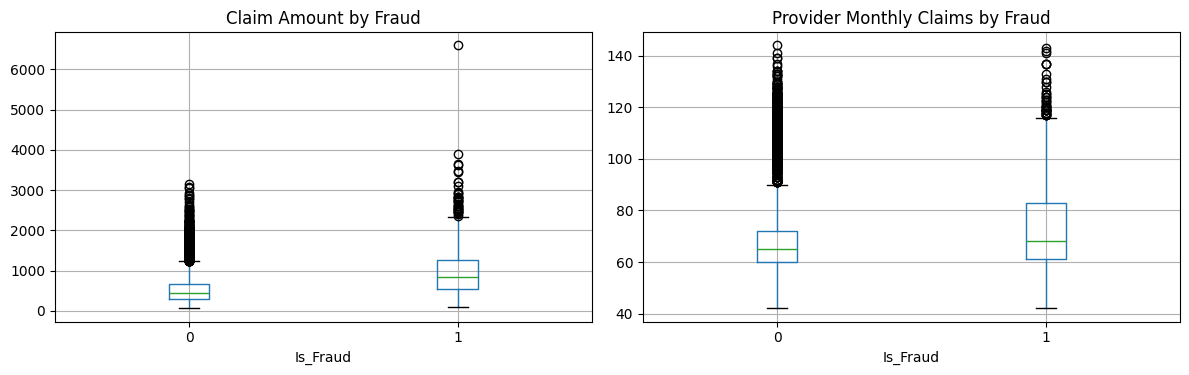

In [10]:
# claim amount distribution by fraud
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.boxplot(column='Claim_Amount', by='Is_Fraud', ax=axes[0])
axes[0].set_title('Claim Amount by Fraud')
axes[0].set_xlabel('Is_Fraud')
df.boxplot(column='Number_of_Claims_Per_Provider_Monthly', by='Is_Fraud', ax=axes[1])
axes[1].set_title('Provider Monthly Claims by Fraud')
axes[1].set_xlabel('Is_Fraud')
plt.suptitle('')
plt.tight_layout()
plt.show()

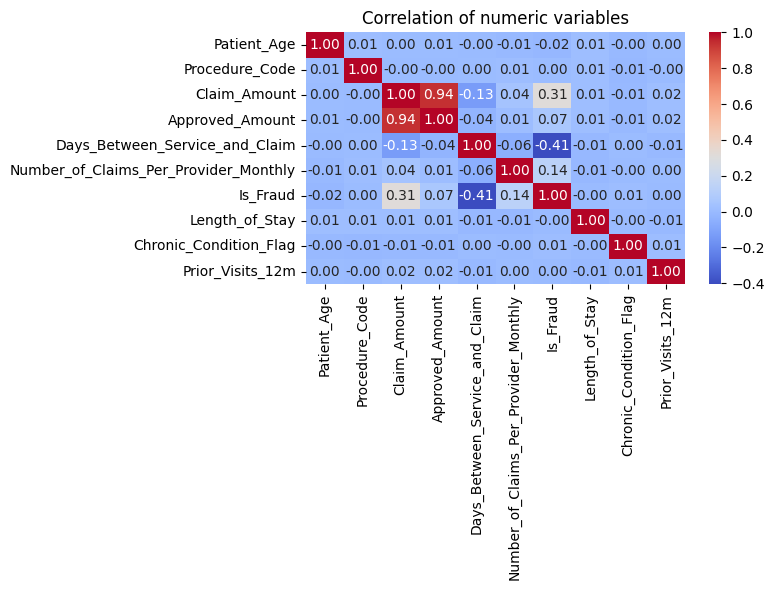

In [11]:
# correlation heatmap of numeric vars
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation of numeric variables')
plt.tight_layout()
plt.show()

## 3. Data Preparation

The model excludes unique identifiers, `Claim_Status` because of leakage risk, and `Claim_Submission_Date` because date-based feature engineering is outside this project's scope. Missing values are handled inside the preprocessing pipeline so that imputation is learned only from training data.

In [12]:
drop_cols = ['Provider_ID', 'Claim_ID', 'Claim_Status', 'Claim_Submission_Date']
df_model = df.drop(columns=drop_cols)

y = df_model['Is_Fraud']
X = df_model.drop(columns=['Is_Fraud'])

print('predictors:', X.shape[1])
print('target balance:', y.value_counts(normalize=True).round(3).to_dict())

predictors: 15
target balance: {0: 0.917, 1: 0.083}


In [13]:
# identify categorical vs numerical
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()
print('categorical:', categorical_cols)
print('numerical:', numerical_cols)

categorical: ['Patient_Gender', 'Diagnosis_Code', 'Insurance_Type', 'Provider_Specialty', 'Patient_State', 'Visit_Type']
numerical: ['Patient_Age', 'Procedure_Code', 'Claim_Amount', 'Approved_Amount', 'Days_Between_Service_and_Claim', 'Number_of_Claims_Per_Provider_Monthly', 'Length_of_Stay', 'Chronic_Condition_Flag', 'Prior_Visits_12m']


In [14]:
# train test split, stratified on the target since fraud is rare
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
print('train:', X_train.shape, '  test:', X_test.shape)
print('train fraud rate:', y_train.mean().round(4))
print('test fraud rate :', y_test.mean().round(4))

train: (7000, 15)   test: (3000, 15)
train fraud rate: 0.0829
test fraud rate : 0.083


In [15]:
# preprocessing pipeline
# numeric: median imputation + standardization (kNN needs scaling)
# categorical: mode imputation + one hot encoding

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, numerical_cols),
    ('cat', cat_pipe, categorical_cols)
])

# fit on training data, transform both
X_train_t = preprocessor.fit_transform(X_train)
X_test_t  = preprocessor.transform(X_test)
print('shape after preprocessing:', X_train_t.shape)

shape after preprocessing: (7000, 42)


### Handling Class Imbalance

Fraud represents only about 8.3% of the data. A model predicting “not fraud” for every claim would appear accurate while providing no business value. Random oversampling is therefore applied only to the training data*. The test set remains untouched so final metrics reflect the original class distribution.

In [16]:
ros = RandomOverSampler(random_state=42)
X_train_os, y_train_os = ros.fit_resample(X_train_t, y_train)
print('before oversampling:', np.bincount(y_train))
print('after  oversampling:', np.bincount(y_train_os))

before oversampling: [6420  580]
after  oversampling: [6420 6420]


## 4. Logistic Regression

Logistic regression serves as the interpretable baseline. It is well suited to binary classification, produces probabilities that can support risk-based prioritization, and allows coefficient-based interpretation.

In [17]:
log_model = LogisticRegression(max_iter=5000, random_state=42)
log_model.fit(X_train_os, y_train_os)
log_pred = log_model.predict(X_test_t)
log_proba = log_model.predict_proba(X_test_t)[:, 1]

print('Accuracy :', round(accuracy_score(y_test, log_pred), 4))
print('Precision:', round(precision_score(y_test, log_pred), 4))
print('Recall   :', round(recall_score(y_test, log_pred), 4))
print('F1 Score :', round(f1_score(y_test, log_pred), 4))
print('ROC AUC  :', round(roc_auc_score(y_test, log_proba), 4))
print()
print(classification_report(y_test, log_pred))

Accuracy : 0.9777
Precision: 0.8095
Recall   : 0.9558
F1 Score : 0.8766
ROC AUC  : 0.9976

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      2751
           1       0.81      0.96      0.88       249

    accuracy                           0.98      3000
   macro avg       0.90      0.97      0.93      3000
weighted avg       0.98      0.98      0.98      3000



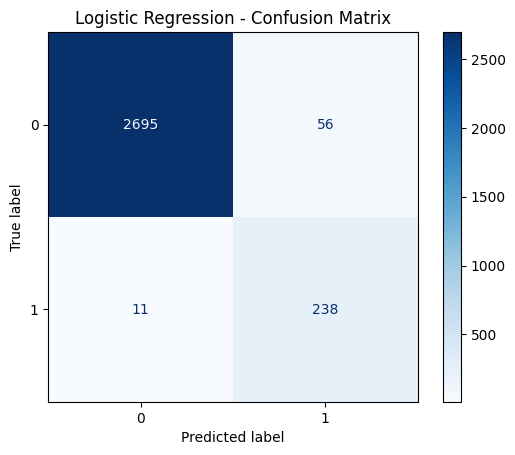

In [18]:
# confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, log_pred, cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

The model catches 238 of the 249 fraudulent claims in the test set, producing recall of approximately 95.6%. It also flags 56 legitimate claims for review. In a screening workflow, this tradeoff may be acceptable because flagged claims would be reviewed by investigators rather than automatically denied.

## 5. Decision Tree

A decision tree can capture nonlinear relationships and interactions while remaining relatively explainable. Tree depth is limited to reduce overfitting.

In [19]:
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train_os, y_train_os)
tree_pred = tree_model.predict(X_test_t)
tree_proba = tree_model.predict_proba(X_test_t)[:, 1]

print('Accuracy :', round(accuracy_score(y_test, tree_pred), 4))
print('Precision:', round(precision_score(y_test, tree_pred), 4))
print('Recall   :', round(recall_score(y_test, tree_pred), 4))
print('F1 Score :', round(f1_score(y_test, tree_pred), 4))
print('ROC AUC  :', round(roc_auc_score(y_test, tree_proba), 4))
print()
print(classification_report(y_test, tree_pred))

Accuracy : 0.908
Precision: 0.4733
Recall   : 0.9598
F1 Score : 0.634
ROC AUC  : 0.9726

              precision    recall  f1-score   support

           0       1.00      0.90      0.95      2751
           1       0.47      0.96      0.63       249

    accuracy                           0.91      3000
   macro avg       0.73      0.93      0.79      3000
weighted avg       0.95      0.91      0.92      3000



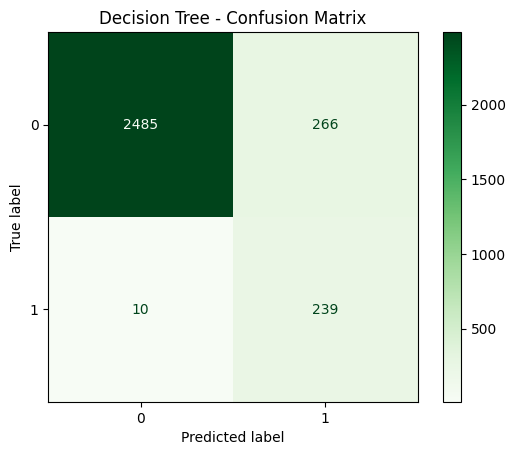

In [20]:
ConfusionMatrixDisplay.from_predictions(y_test, tree_pred, cmap='Greens')
plt.title('Decision Tree - Confusion Matrix')
plt.show()

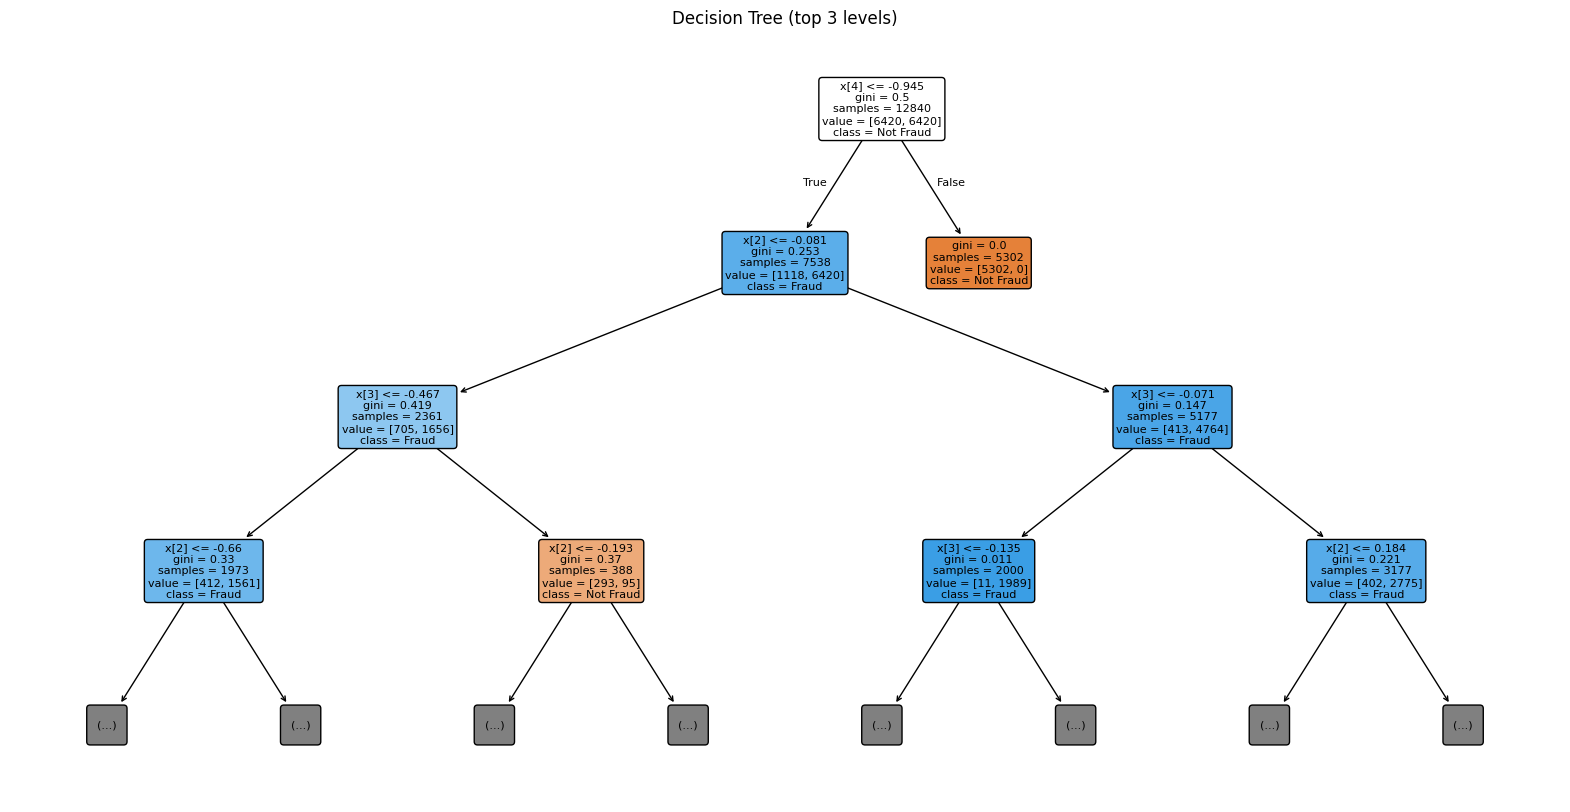

In [21]:
# plot the tree to see what it learned
plt.figure(figsize=(20, 10))
plot_tree(tree_model, filled=True, rounded=True,
          class_names=['Not Fraud', 'Fraud'], fontsize=8, max_depth=3)
plt.title('Decision Tree (top 3 levels)')
plt.show()

The decision tree achieves recall similar to logistic regression, but its precision is substantially lower. More than half of the claims it flags are false positives, which would create a heavier review workload and could reduce investigator trust in the system.

## 6. k-Nearest Neighbors

k-nearest neighbors is a distance-based, nonparametric method. Because its performance is sensitive to feature scale, numeric variables are standardized. Candidate values of `k` are selected using cross-validation on the training data, keeping the test set reserved for final evaluation.

In [22]:
# Select k using stratified cross-validation on the training data only.
# Oversampling occurs inside each fold to avoid validation leakage.

candidate_k = [3, 5, 7, 9, 11, 15, 21]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
k_results = []

for k in candidate_k:
    knn_cv_pipeline = ImbPipeline([
        ('preprocessor', preprocessor),
        ('oversampler', RandomOverSampler(random_state=42)),
        ('model', KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(
        knn_cv_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring='f1',
        n_jobs=-1
    )
    k_results.append({
        'k': k,
        'Mean CV F1': scores.mean(),
        'CV F1 Std': scores.std()
    })

k_df = pd.DataFrame(k_results)
k_df.round(4)

,k,Mean CV F1,CV F1 Std
0,3,0.4302,0.0248
1,5,0.4304,0.0227
2,7,0.4296,0.0215
3,9,0.4150,0.0223
4,11,0.4016,0.0203
5,15,0.3942,0.0198
6,21,0.4009,0.0142


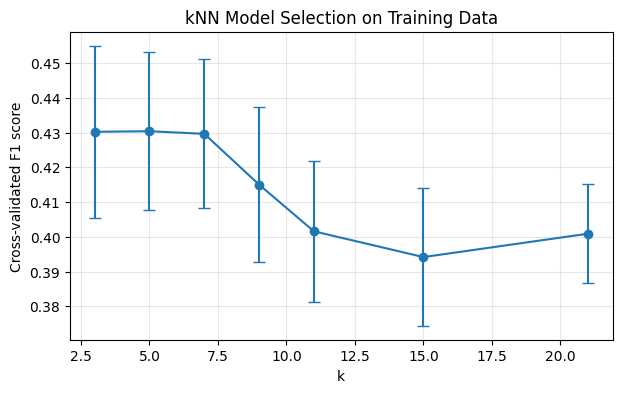

In [23]:
# Cross-validated F1 score for each candidate value of k
plt.figure(figsize=(7, 4))
plt.errorbar(
    k_df['k'],
    k_df['Mean CV F1'],
    yerr=k_df['CV F1 Std'],
    marker='o',
    capsize=4
)
plt.xlabel('k')
plt.ylabel('Cross-validated F1 score')
plt.title('kNN Model Selection on Training Data')
plt.grid(alpha=0.3)
plt.show()

In [24]:
# Fit the final kNN model using the best cross-validated k,
# then evaluate once on the untouched test set.
best_k = int(k_df.loc[k_df['Mean CV F1'].idxmax(), 'k'])
print('Selected k:', best_k)

knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_os, y_train_os)
knn_pred = knn_model.predict(X_test_t)
knn_proba = knn_model.predict_proba(X_test_t)[:, 1]

print('Accuracy :', round(accuracy_score(y_test, knn_pred), 4))
print('Precision:', round(precision_score(y_test, knn_pred), 4))
print('Recall   :', round(recall_score(y_test, knn_pred), 4))
print('F1 Score :', round(f1_score(y_test, knn_pred), 4))
print('ROC AUC  :', round(roc_auc_score(y_test, knn_proba), 4))
print()
print(classification_report(y_test, knn_pred))

Selected k: 5
Accuracy : 0.8677
Precision: 0.3405
Recall   : 0.6345
F1 Score : 0.4432
ROC AUC  : 0.8195

              precision    recall  f1-score   support

           0       0.96      0.89      0.92      2751
           1       0.34      0.63      0.44       249

    accuracy                           0.87      3000
   macro avg       0.65      0.76      0.68      3000
weighted avg       0.91      0.87      0.88      3000



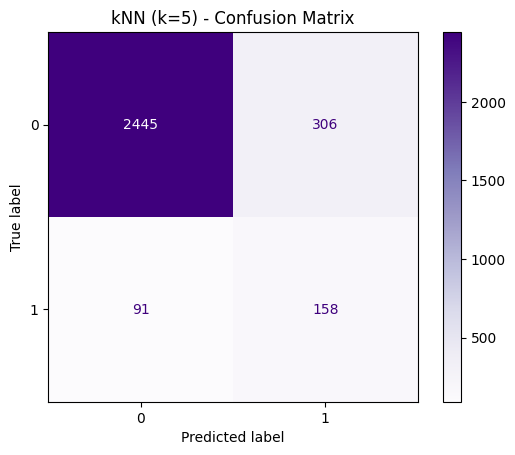

In [25]:
ConfusionMatrixDisplay.from_predictions(y_test, knn_pred, cmap='Purples')
plt.title(f'kNN (k={best_k}) - Confusion Matrix')
plt.show()

kNN performs substantially worse than the other two approaches. The results suggest that fraud cases are not well separated by simple distance in the transformed feature space; instead, performance appears to depend more on combinations of financial, provider, and claim characteristics.

## 7. Model Comparison

In [26]:
# Compare final test-set performance
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', f'kNN (k={best_k})'],
    'Accuracy': [accuracy_score(y_test, log_pred),
                 accuracy_score(y_test, tree_pred),
                 accuracy_score(y_test, knn_pred)],
    'Precision': [precision_score(y_test, log_pred),
                  precision_score(y_test, tree_pred),
                  precision_score(y_test, knn_pred)],
    'Recall': [recall_score(y_test, log_pred),
               recall_score(y_test, tree_pred),
               recall_score(y_test, knn_pred)],
    'F1': [f1_score(y_test, log_pred),
           f1_score(y_test, tree_pred),
           f1_score(y_test, knn_pred)],
    'ROC AUC': [roc_auc_score(y_test, log_proba),
                roc_auc_score(y_test, tree_proba),
                roc_auc_score(y_test, knn_proba)]
})
comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Logistic Regression,0.9777,0.8095,0.9558,0.8766,0.9976
1,Decision Tree,0.9080,0.4733,0.9598,0.6340,0.9726
2,kNN (k=5),0.8677,0.3405,0.6345,0.4432,0.8195


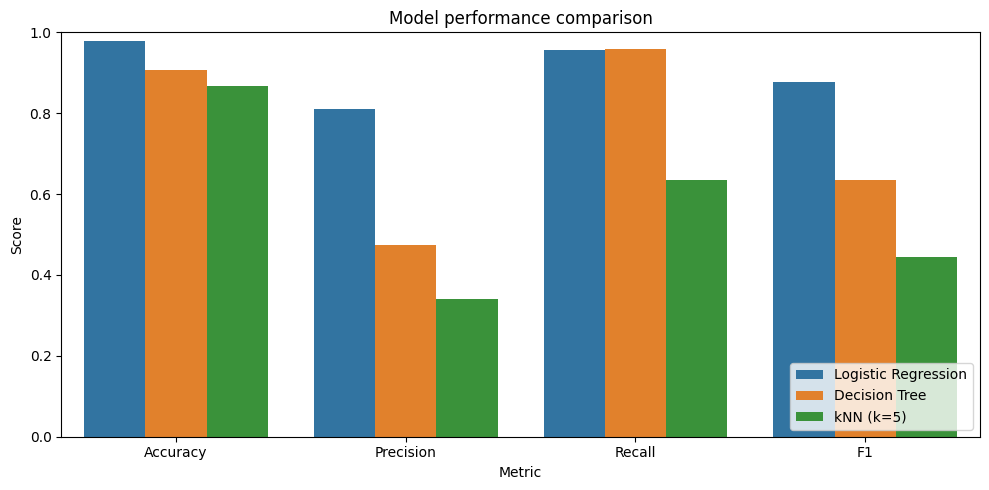

In [27]:
# bar chart comparing the three on the four key metrics
metrics_long = comparison.melt(id_vars='Model', value_vars=['Accuracy', 'Precision', 'Recall', 'F1'],
                                var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_long, x='Metric', y='Score', hue='Model')
plt.title('Model performance comparison')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

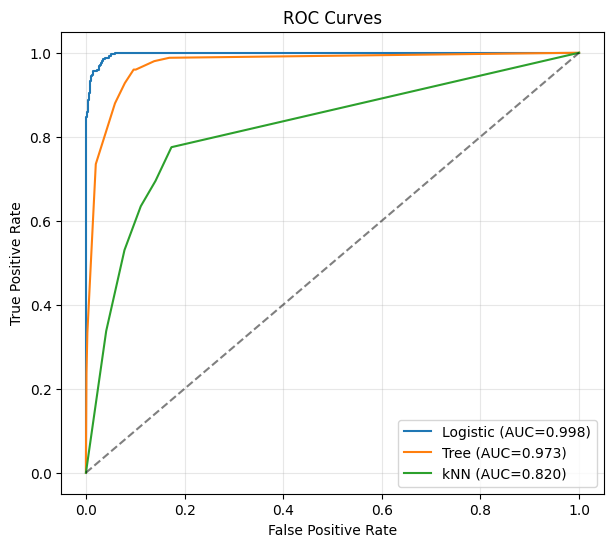

In [28]:
# ROC curves
plt.figure(figsize=(7, 6))
for name, proba in [('Logistic', log_proba), ('Tree', tree_proba), ('kNN', knn_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Logistic regression provides the strongest overall balance of precision, recall, F1 score, and ROC AUC. The decision tree achieves similar recall but creates far more false positives, while kNN trails both models across the most important metrics.

## 8. Model Interpretation

Logistic regression coefficients provide a directional view of which transformed features most strongly influence fraud predictions. Because numeric variables are standardized, their coefficient magnitudes are more comparable than they would be on their original scales.

In [29]:
# pull out feature names from the preprocessor
feature_names = (numerical_cols +
                 list(preprocessor.named_transformers_['cat']
                      .named_steps['encoder']
                      .get_feature_names_out(categorical_cols)))

coefs = pd.DataFrame({
    'feature': feature_names,
    'coefficient': log_model.coef_[0]
})
coefs['abs_coef'] = coefs['coefficient'].abs()
top15 = coefs.sort_values('abs_coef', ascending=False).head(15)
top15[['feature', 'coefficient']]

,feature,coefficient
2,Claim_Amount,14.712289
3,Approved_Amount,-14.454938
4,Days_Between_Service_and_Claim,-4.310465
36,Patient_State_OH,-0.624891
12,Diagnosis_Code_E78.5,0.596687
27,Provider_Specialty_Internal Medicine,0.525315
35,Patient_State_NY,-0.480248
13,Diagnosis_Code_F41.9,-0.475571
16,Diagnosis_Code_J06.9,-0.417944
30,Provider_Specialty_Pulmonology,-0.363443


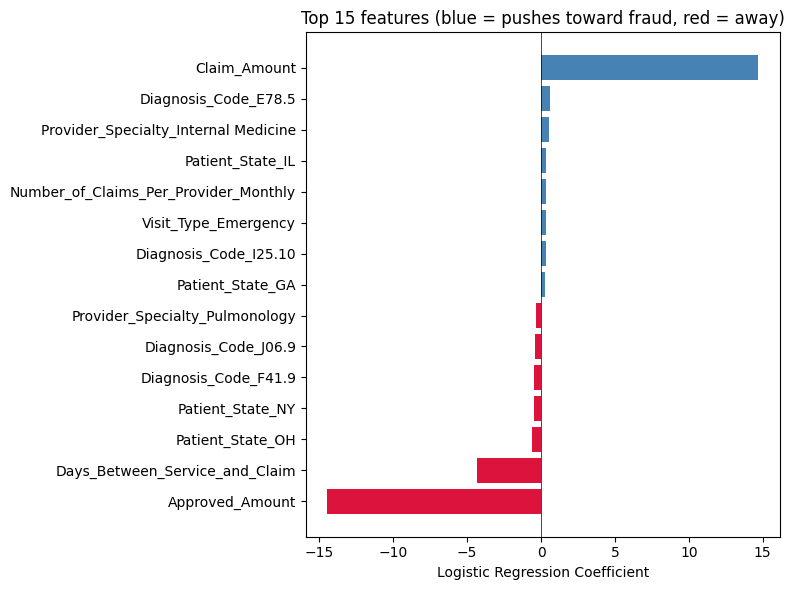

In [30]:
# plot top features
plt.figure(figsize=(8, 6))
top15_sorted = top15.sort_values('coefficient')
colors = ['steelblue' if c > 0 else 'crimson' for c in top15_sorted['coefficient']]
plt.barh(top15_sorted['feature'], top15_sorted['coefficient'], color=colors)
plt.xlabel('Logistic Regression Coefficient')
plt.title('Top 15 features (blue = pushes toward fraud, red = away)')
plt.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## 9. Limitations and Next Steps

- **Synthetic dataset:** The data comes from Kaggle and may contain cleaner or more stable patterns than real insurance claims.
- **Post-adjudication feature:** `Approved_Amount` may not be available when a claim is first submitted. A pre-adjudication screening model should remove it and compare the resulting performance.
- **Oversampling approach:** Random oversampling is simple and effective here, but future work should compare class weighting, SMOTE, and cost-sensitive learning.
- **Model scope:** Gradient-boosting methods such as XGBoost or CatBoost may improve performance on tabular data and should be evaluated with cross-validation.
- **Operational evaluation:** A production study should translate false positives and false negatives into investigation costs, expected savings, and threshold-selection rules.
- **Monitoring:** Real fraud patterns change over time, so any deployed system would require drift monitoring and periodic retraining.

## 10. Conclusion

Logistic regression with random oversampling is the recommended model in this analysis. It catches 238 of 249 fraudulent claims in the test set, corresponding to approximately 95.6% recall, while maintaining about 81% precision.

For every 3,000 claims, the model would flag roughly 294 for investigator review. About 238 of those would be fraudulent and 56 would be false positives, leaving 11 fraudulent claims undetected. This makes the model useful as a **human-in-the-loop prioritization tool**, not as an automated denial system.

The most influential signals include billed and approved claim amounts, the time between service and submission, provider claim volume, and selected categorical combinations. The next development step would be to evaluate a pre-adjudication version without `Approved_Amount` and compare gradient-boosting models using a cost-sensitive business objective.